In [1]:
###############################################################################################
############################## 1.CRIAÇÃO DE UM DATASET RANDOMICO ##############################
###############################################################################################


import numpy as np
import pandas as pd
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Normalization
from tensorflow.keras.layers import Dense, Dropout


np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "idade": np.random.randint(18, 70, n),
    "tempo_cliente_meses": np.random.randint(1, 120, n),
    "uso_medio_diario": np.random.uniform(0.1, 5.0, n),
    "tickets_suporte": np.random.randint(0, 10, n),
    "plano_premium": np.random.binomial(1, 0.4, n),
    "pagamento_atrasado": np.random.binomial(1, 0.2, n),
    "desconto_ativo": np.random.binomial(1, 0.3, n),
    "visitas_semanais": np.random.randint(0, 20, n),
    "dispositivos": np.random.randint(1, 5, n),
    "satisfacao": np.random.uniform(0, 10, n)
})

# Probabilidade de churn (regra oculta)
logit = (
    -0.3 * data["satisfacao"]
    -0.2 * data["uso_medio_diario"]
    +0.5 * data["pagamento_atrasado"]
    +0.4 * data["tickets_suporte"]
    -0.3 * data["plano_premium"]
)

prob_churn = 1 / (1 + np.exp(-logit))

data["churn"] = np.random.binomial(1, prob_churn)

data.head()

,idade,tempo_cliente_meses,uso_medio_diario,tickets_suporte,plano_premium,pagamento_atrasado,desconto_ativo,visitas_semanais,dispositivos,satisfacao,churn
0,56,99,4.177457,2,0,0,0,0,1,8.533957,0
1,69,115,2.586592,0,1,0,1,9,2,9.143404,1
2,46,15,0.131291,3,0,0,0,5,2,2.652851,1
3,32,64,1.506487,1,0,0,0,11,4,9.039531,0
4,60,89,3.122942,1,0,0,0,3,1,3.206628,0


In [2]:
###############################################################################################
################### 2.SEPARAR O X E Y PARA TREINAMENTO E VALIDAÇÃO DO MODELO ##################
###############################################################################################





#CRIAÇAO DO X E y
X = data.drop(columns=["churn"])
y = data["churn"]

# 80% treino, 20% validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)





In [3]:
###############################################################################################
#################### 3.NORMALIZAÇÃO DAS FEATURES & ESTRUTURAÇÃO DO MODELO #####################
###############################################################################################


# mudar para numpy
X_train = X_train.to_numpy()
X_val   = X_val.to_numpy()


# criar a layer
normalizer = Normalization(axis=-1) ###axis=-1 → normaliza cada feature independentemente

# adaptar apenas nos dados de treino
normalizer.adapt(X_train) ###adapt(X_train) → calcula média e desvio padrão apenas do treino

# entrada
inputs = Input(shape=(X_train.shape[1],))  # 10 features isso porque X_train.shape vai devolver uma tupla (800,10) entao indíce 1 é o valor "10"
x = normalizer(inputs)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)

outputs = Dense(1, activation='sigmoid')(x) #sempre sigmoide quando o valor esperado é um problema binário





In [4]:
###############################################################################################
#################################### 4.COMPILAR O MODELO ######################################
###############################################################################################



# montar modelo
model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Configurar EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)



In [5]:
###############################################################################################
################################## 5.TREINAMENTO DO  MODELO ###################################
###############################################################################################

story = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop]
)




Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5188 - loss: 0.7061 - val_accuracy: 0.6750 - val_loss: 0.6441
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6450 - loss: 0.6392 - val_accuracy: 0.6450 - val_loss: 0.6157
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7088 - loss: 0.6070 - val_accuracy: 0.6900 - val_loss: 0.5890
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7163 - loss: 0.5918 - val_accuracy: 0.7150 - val_loss: 0.5718
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7387 - loss: 0.5668 - val_accuracy: 0.7200 - val_loss: 0.5511
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7375 - loss: 0.5486 - val_accuracy: 0.7250 - val_loss: 0.5386
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7312 - loss: 0.5278 - val_accuracy: 0.7300 - val_loss: 0.5315
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7462 - loss: 0.5239 - val_accuracy: 0.7200 - v

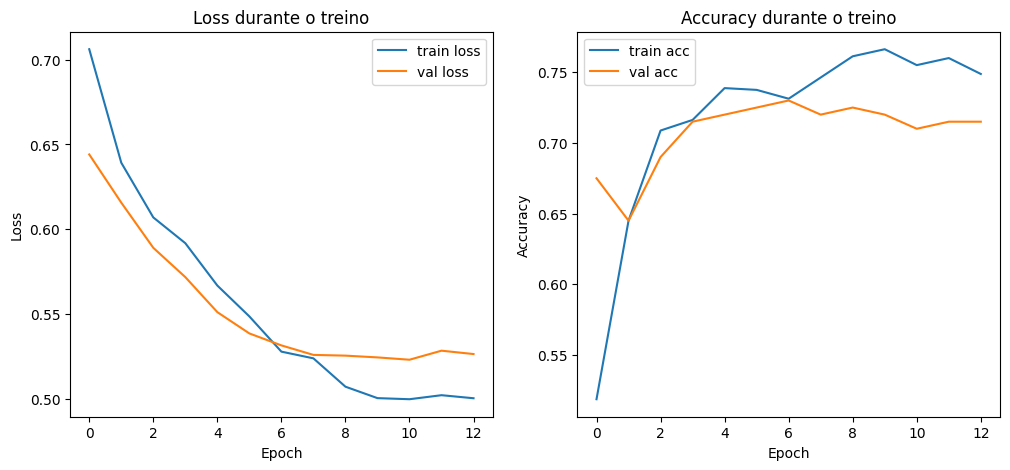

In [6]:
###############################################################################################
################################## 6.VERIFICAÇÃO DE METRICAS ##################################
###############################################################################################


import matplotlib.pyplot as plt

# extrair dados do histórico
loss = story.history['loss']
val_loss = story.history['val_loss']
accuracy = story.history['accuracy']
val_accuracy = story.history['val_accuracy']

# plotar Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss durante o treino')
plt.legend()

# plotar Accuracy
plt.subplot(1,2,2)
plt.plot(accuracy, label='train acc')
plt.plot(val_accuracy, label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy durante o treino')
plt.legend()

plt.show()

In [ ]:
###############################################################################################
################################## 7.APLICAÇÃO NOS DADOS REAIS ################################
###############################################################################################


X_real = df_real.to_numpy()        # converter dataframe real para numpy
X_real = normalizer(X_real)        # aplicar normalização já adaptada no treino

y_pred_prob = model.predict(X_real)      # retorna probabilidade de churn
y_pred_class = (y_pred_prob > 0.5).astype(int)  # converte em 0 ou 1